In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # FEM builders
    plan, build_elements, build_load_vector,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d, plot_gmsh_mesh,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m, mm , N,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 1.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [3]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [4]:
# General model parameters
L = 1000 
H = 1000  
B = 10
lc = 50
R = 200 
output_path = os.getcwd()
mesh_name = 'plate_with_hole'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [5]:
# Create a new GMSH model
gmsh.initialize()
gmsh.model.add(mesh_name)

# Create the corner points of the beam
p1 = gmsh.model.geo.addPoint(0, 0, 0, lc)
p2 = gmsh.model.geo.addPoint(L, 0, 0, lc)
p3 = gmsh.model.geo.addPoint(L, H, 0, lc)
p4 = gmsh.model.geo.addPoint(0, H, 0, lc)

# Define the outer rectangle lines
l1 = gmsh.model.geo.addLine(p1, p2)  # Base
l2 = gmsh.model.geo.addLine(p2, p3)  # Lateral derecho
l3 = gmsh.model.geo.addLine(p3, p4)  # Tope
l4 = gmsh.model.geo.addLine(p4, p1)  # Lateral izquierdo

# Create the outer curve loop
c1 = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])

# Create the circular hole in the center (4 puntos para que sea divisible por 2)
center_x = L / 2
center_y = H / 2
pc = gmsh.model.geo.addPoint(center_x, center_y, 0, lc)
p_right = gmsh.model.geo.addPoint(center_x + R, center_y, 0, lc)
p_top = gmsh.model.geo.addPoint(center_x, center_y + R, 0, lc)
p_left = gmsh.model.geo.addPoint(center_x - R, center_y, 0, lc)
p_bottom = gmsh.model.geo.addPoint(center_x, center_y - R, 0, lc)

# Create four quarter-circle arcs
arc1 = gmsh.model.geo.addCircleArc(p_right, pc, p_top)
arc2 = gmsh.model.geo.addCircleArc(p_top, pc, p_left)
arc3 = gmsh.model.geo.addCircleArc(p_left, pc, p_bottom)
arc4 = gmsh.model.geo.addCircleArc(p_bottom, pc, p_right)

# Create the hole curve loop
c2 = gmsh.model.geo.addCurveLoop([arc1, arc2, arc3, arc4])

# Create the surface with the hole
s1 = gmsh.model.geo.addPlaneSurface([c1, c2])

# Synchronize the model
gmsh.model.geo.synchronize()

# Create the physical groups
gmsh.model.addPhysicalGroup(2, [s1], 201)
gmsh.model.setPhysicalName(2, 201, "Beam")

# Apoyo en lado izquierdo (empotrado)
gmsh.model.addPhysicalGroup(1, [l4], 101) 
gmsh.model.setPhysicalName(1, 101, "Support1")

# Carga en el lado derecho
gmsh.model.addPhysicalGroup(1, [l2], 50) 
gmsh.model.setPhysicalName(1, 50, "Load")

# Synchronize the model
gmsh.model.geo.synchronize()

def all_quads():
    gmsh.model.geo.synchronize()
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.Algorithm", 8)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.Smoothing", 100)
    gmsh.option.setNumber("Mesh.ElementOrder", 1)

# all_quads()
# gmsh.option.setNumber("Mesh.ElementOrder", 2)


# Generate and save mesh
# gmsh.model.mesh.generate()
# gmsh.write(output_file)
# gmsh.fltk.run()
# gmsh.finalize()

In [6]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [7]:
# Define material
Steel = Material(name='Steel',
             E=200000.00, #Mpa
             nu=0.30,
             rho= 7850*kg/m**3*g)

# Define membrane section
SteelPlate = Membrane(name='SteelPlate',
                        thickness=B,
                        material=Steel)

# Map physical group id to section
section_dictionary = {201: SteelPlate}
                    
# Load magnitude
Pload = 10
load_dictionary = {
    50: {'value': 1*N/(mm*mm), 'direction': 'x'}
}

# Boundary conditions
restrain_dictionary = {101: ['r', 'r']}

In [8]:
# Read mesh
mesh = GMSHtools(output_file)
node_map, system_nDof = plan(mesh, restrain_dictionary)


  MESH SUMMARY

  === NODES ===  (513 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2      1000.0000         0.0000         0.0000
       3      1000.0000      1000.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (3 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      50      1   'Load'
     101      1   'Support1'
     201      2   'Beam'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (3 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      50      1        1          2           20   'Load'
     101      1        1      

In [27]:
mesh.elements

{50: {'dim': 1,
  'gmsh_type': 1,
  'n_nodes': 2,
  'element_tags': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20],
  'connectivity': [[2, 28],
   [28, 29],
   [29, 30],
   [30, 31],
   [31, 32],
   [32, 33],
   [33, 34],
   [34, 35],
   [35, 36],
   [36, 37],
   [37, 38],
   [38, 39],
   [39, 40],
   [40, 41],
   [41, 42],
   [42, 43],
   [43, 44],
   [44, 45],
   [45, 46],
   [46, 3]]},
 101: {'dim': 1,
  'gmsh_type': 1,
  'n_nodes': 2,
  'element_tags': [21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40],
  'connectivity': [[4, 66],
   [66, 67],
   [67, 68],
   [68, 69],
   [69, 70],
   [70, 71],
   [71, 72],
   [72, 73],
   [73, 74],
   [74, 75],
   [75, 76],
   [76, 77],
   [77, 78],
   [78, 79],
   [79, 80],
   [80, 81],
   [81, 82],
   [82, 83],
   [83, 84],
   [84, 1]]},
 201: {'dim': 2,
  'gmsh_type': 2,
  'n_no

In [9]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

elements = build_elements(
    mesh               = mesh,
    node_map           = node_map,
    section_dictionary = section_dictionary,
    element_class_map  = element_map,
    load_dictionary    = load_dictionary,
    type               = 'planeStrain',
    sampling_points    = 3,
    eval_points        = [0, 0],
)

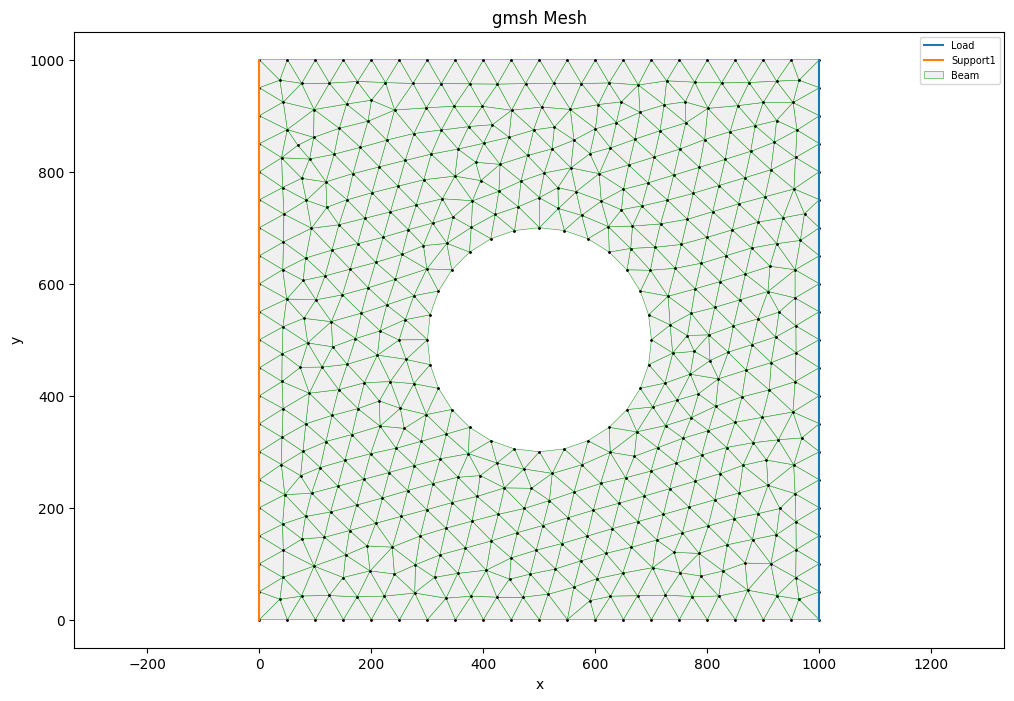

In [10]:
# %matplotlib widge
plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = True,
            #    view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

In [11]:
# Build global nodal force vector from load dictionary = body + surface
F_load = np.zeros(system_nDof)
for elem in elements:
    F_load[elem.idx] += elem.F_fe_global

F_load += build_load_vector(mesh, node_map, load_dictionary, system_nDof)

In [12]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Assembly
K = lil_matrix((system_nDof, system_nDof))
for element in elements:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in node_map.values():
    F[node.idx] += node.nodalLoad
F += F_load

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in node_map.values()])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, F[free_dofs] - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr = Krf @ uf + Krr @ ur
R  = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [13]:
# Reactions per node
for node in node_map.values():
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' * 50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 1:  Rx=-625.812280  Ry=-260.314843
Node 4:  Rx=-842.136933  Ry=+345.433935
Node 66:  Rx=-1040.201854  Ry=+189.865297
Node 67:  Rx=-847.388082  Ry=+116.908691
Node 68:  Rx=-734.461370  Ry=+50.429154
Node 69:  Rx=-630.400012  Ry=+26.028654
Node 70:  Rx=-524.302632  Ry=-1.974584
Node 71:  Rx=-419.164792  Ry=-25.162312
Node 72:  Rx=-328.508808  Ry=-29.140963
Node 73:  Rx=-249.323046  Ry=-21.474628
Node 74:  Rx=-194.726713  Ry=+14.943922
Node 75:  Rx=-179.327418  Ry=+45.339907
Node 76:  Rx=-201.094487  Ry=+76.773511
Node 77:  Rx=-254.577781  Ry=+94.767515
Node 78:  Rx=-325.984086  Ry=+98.951236
Node 79:  Rx=-408.894165  Ry=+81.957088
Node 80:  Rx=-487.691015  Ry=+62.912949
Node 81:  Rx=-560.611188  Ry=+16.771815
Node 82:  Rx=-637.723039  Ry=-20.548608
Node 83:  Rx=-695.359845  Ry=-69.342039
Node 84:  Rx=-812.310452  Ry=-135.286261
----------------------------------------------------------------------------------------------------
Applied X:  +11000.0000   Reaction X: -11000.0000   Bala

In [14]:
for node in node_map.values():
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        print(f"Node {node.name} at {node.coordinates}:  Fx={fx:+.4f}  Fy={fy:+.4f}")

Node 1 at [0. 0.]:  Fx=+0.0000  Fy=-0.4698
Node 2 at [1000.    0.]:  Fx=+275.0000  Fy=-0.4698
Node 3 at [1000. 1000.]:  Fx=+275.0000  Fy=-0.4700
Node 4 at [   0. 1000.]:  Fx=+0.0000  Fy=-0.4700
Node 5 at [700. 500.]:  Fx=+0.0000  Fy=-0.6725
Node 6 at [500. 700.]:  Fx=+0.0000  Fy=-0.9518
Node 7 at [300. 500.]:  Fx=+0.0000  Fy=-0.9488
Node 8 at [500. 300.]:  Fx=+0.0000  Fy=-0.6588
Node 9 at [50.  0.]:  Fx=+0.0000  Fy=-0.6965
Node 10 at [100.   0.]:  Fx=+0.0000  Fy=-0.8217
Node 11 at [150.   0.]:  Fx=+0.0000  Fy=-0.8069
Node 12 at [200.   0.]:  Fx=+0.0000  Fy=-0.7893
Node 13 at [250.   0.]:  Fx=+0.0000  Fy=-0.8897
Node 14 at [300.   0.]:  Fx=+0.0000  Fy=-0.8708
Node 15 at [350.   0.]:  Fx=+0.0000  Fy=-0.7394
Node 16 at [400.   0.]:  Fx=+0.0000  Fy=-0.7706
Node 17 at [450.   0.]:  Fx=+0.0000  Fy=-0.7537
Node 18 at [500.   0.]:  Fx=+0.0000  Fy=-0.8004
Node 19 at [550.   0.]:  Fx=+0.0000  Fy=-1.0909
Node 20 at [600.   0.]:  Fx=+0.0000  Fy=-0.6578
Node 21 at [650.   0.]:  Fx=+0.0000  Fy=-0.80

In [15]:
n_nodes    = len(node_map)
n_elements = len(elements)

# Prepare displacement, force and reaction arrays (3D format for Gmsh)
u_3d = np.zeros((n_nodes, 3))
F_3d = np.zeros((n_nodes, 3))
R_3d = np.zeros((n_nodes, 3))

for i, node in enumerate(node_map.values()):
    u_3d[i, 0] = u[node.idx[0]]
    u_3d[i, 1] = u[node.idx[1]]
    F_3d[i, 0] = F[node.idx[0]]
    F_3d[i, 1] = F[node.idx[1]]
    R_3d[i, 0] = R[node.idx[0]]
    R_3d[i, 1] = R[node.idx[1]]

# Node tags for Gmsh
node_tags = np.array([node.name for node in node_map.values()])

# Stress, strain and Von Mises
sigma_gmsh             = np.zeros((n_elements, 3))
epsilon_gmsh           = np.zeros((n_elements, 3))
sigma_principal_gmsh   = np.zeros((n_elements, 2))
epsilon_principal_gmsh = np.zeros((n_elements, 2))
von_mises_gmsh         = np.zeros(n_elements)
element_tags_list      = []

for i, element in enumerate(elements):
    results = element.get_results(u)
    sigma   = results['stress'].flatten()
    epsilon = results['strain'].flatten()

    sigma_gmsh[i, :]             = sigma
    epsilon_gmsh[i, :]           = epsilon
    sigma_principal_gmsh[i, :]   = results['principal_stress'].flatten()
    epsilon_principal_gmsh[i, :] = results['principal_strain'].flatten()

    sxx, syy, sxy     = sigma
    von_mises_gmsh[i] = np.sqrt(sxx**2 - sxx*syy + syy**2)
    element_tags_list.append(element.element_tag)

In [16]:

# VISUALIZE RESULTS IN GMSH


gmsh.initialize()
gmsh.open(output_file)

# Node tags already computed above
# node_tags = np.array([node.name for node in nodes_list])

# --- Nodal vector fields ---
# VectorType options:
# 1 → Line segments (simple lines)
# 2 → Arrows
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation

add_node_data_view("Displacements",
                   node_tags,
                   u_3d,
                   vector_type=5,
                   factor=5)

add_node_data_view("Applied Loads",
                   node_tags,
                   F_3d,
                   arrow_size_max=60,
                   arrow_size_min=20)

add_node_data_view("Reactions",
                   node_tags,
                   R_3d)

2

In [17]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [18]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [19]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [20]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(elements, 
                                sigma_gmsh[:, 0],   
                                node_map.values())
add_node_data_view("Sxx Nodal Averaged",                 
                    node_tags, sxx_nodal)

# -----------------
syy_nodal = compute_nodal_average(elements, 
                                sigma_gmsh[:, 1],   
                                node_map.values())
add_node_data_view("Syy Nodal Averaged",                 
                    node_tags, syy_nodal)

# -----------------
sxy_nodal = compute_nodal_average(elements, 
                                sigma_gmsh[:, 2],   
                                node_map.values())
add_node_data_view("Sxy Nodal Averaged",                 
                    node_tags, sxy_nodal)

# -----------------
s1_nodal = compute_nodal_average(elements, 
                                sigma_principal_gmsh[:, 0],     
                                node_map.values())
add_node_data_view("Principal Stress S1 Nodal Averaged",
                     node_tags, s1_nodal)

# -----------------
s2_nodal = compute_nodal_average(elements, 
                                sigma_principal_gmsh[:, 1],     
                                node_map.values())
add_node_data_view("Principal Stress S2 Nodal Averaged",
                     node_tags, s2_nodal)

# -----------------
vm_nodal = compute_nodal_average(elements, 
                                von_mises_gmsh,     
                                node_map.values())
add_node_data_view("Von Mises Nodal Averaged",          
                     node_tags, vm_nodal)

# -----------------
exx_nodal = compute_nodal_average(elements, 
                                epsilon_gmsh[:, 0],     
                                node_map.values())
add_node_data_view("Strain Exx Averaged",                
                    node_tags, exx_nodal)

# -----------------
# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

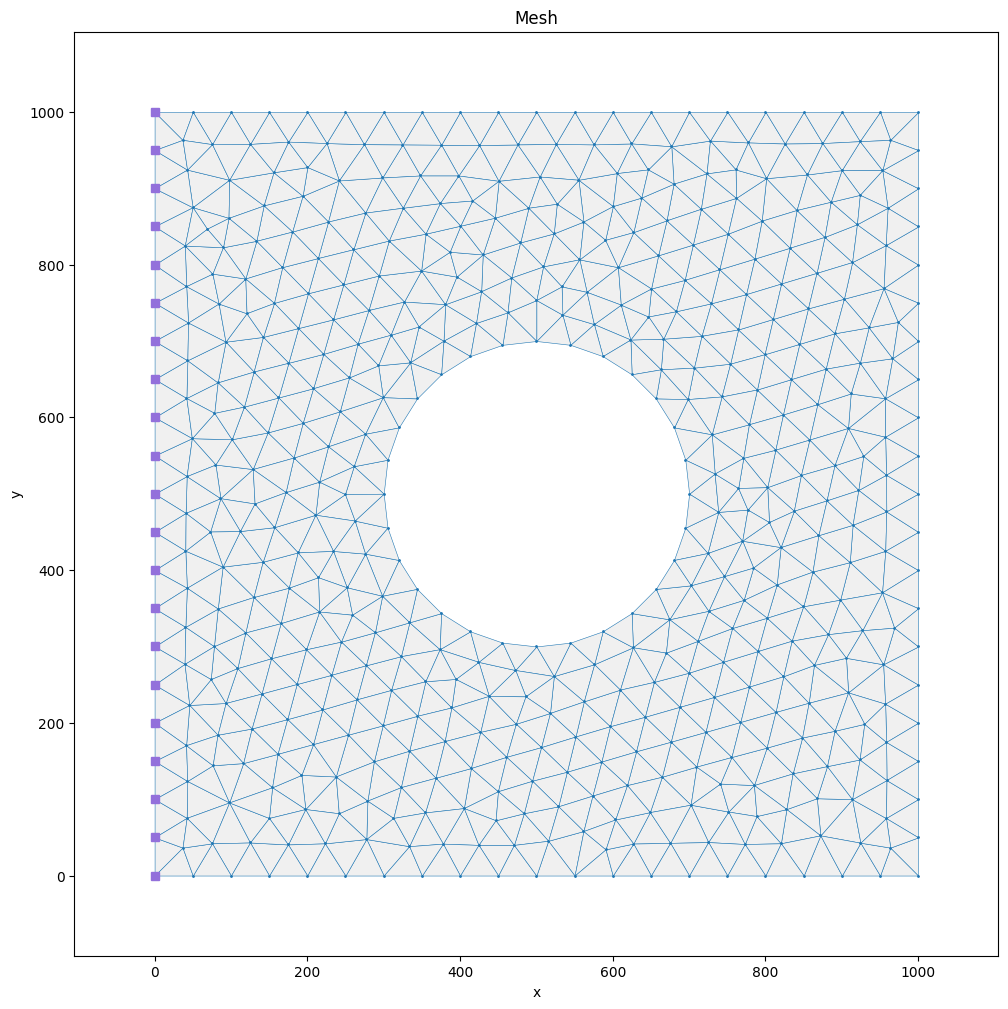

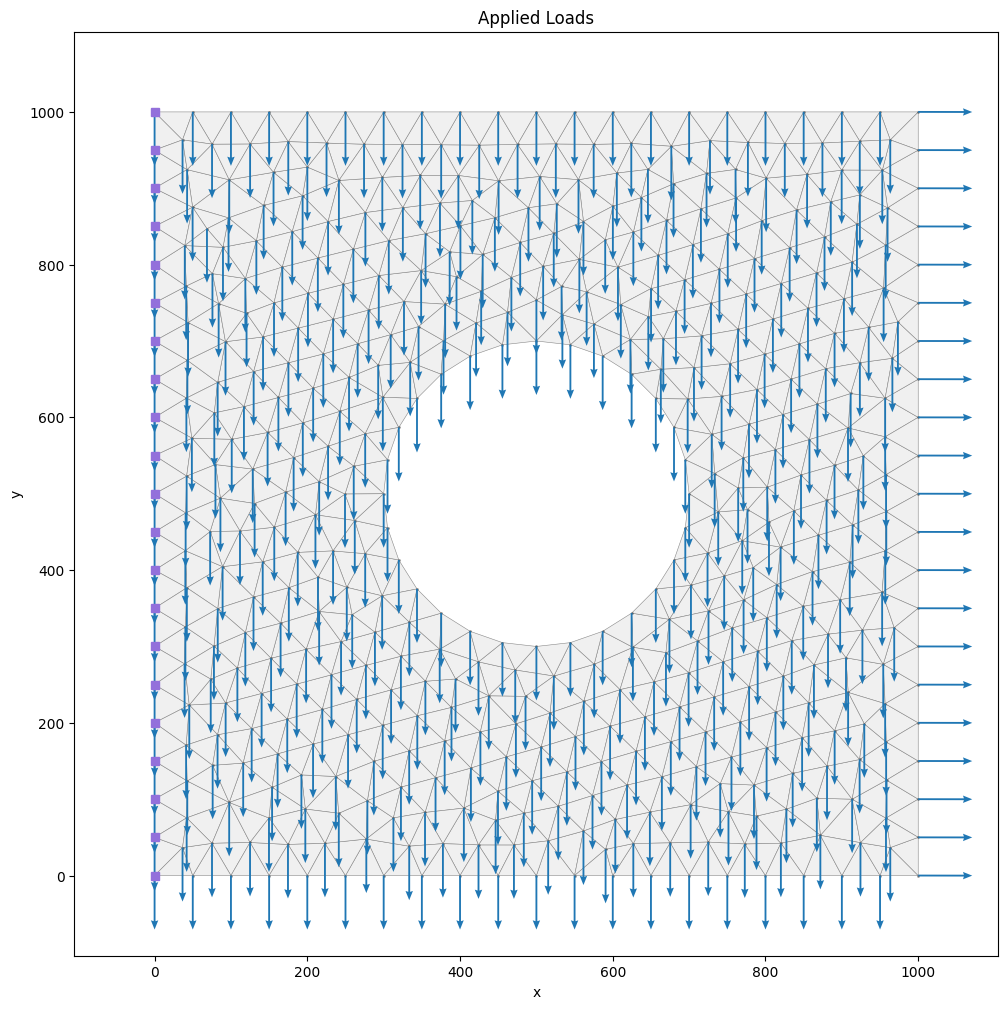

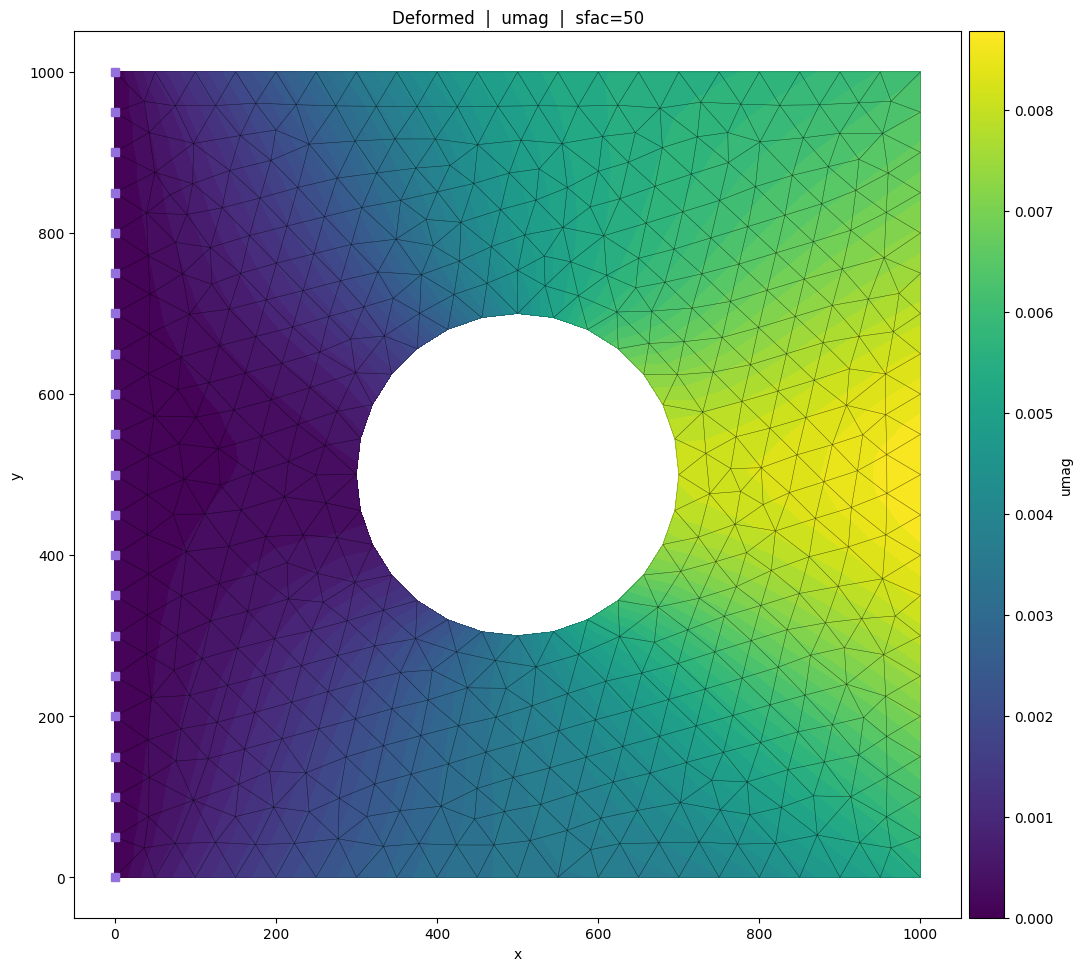

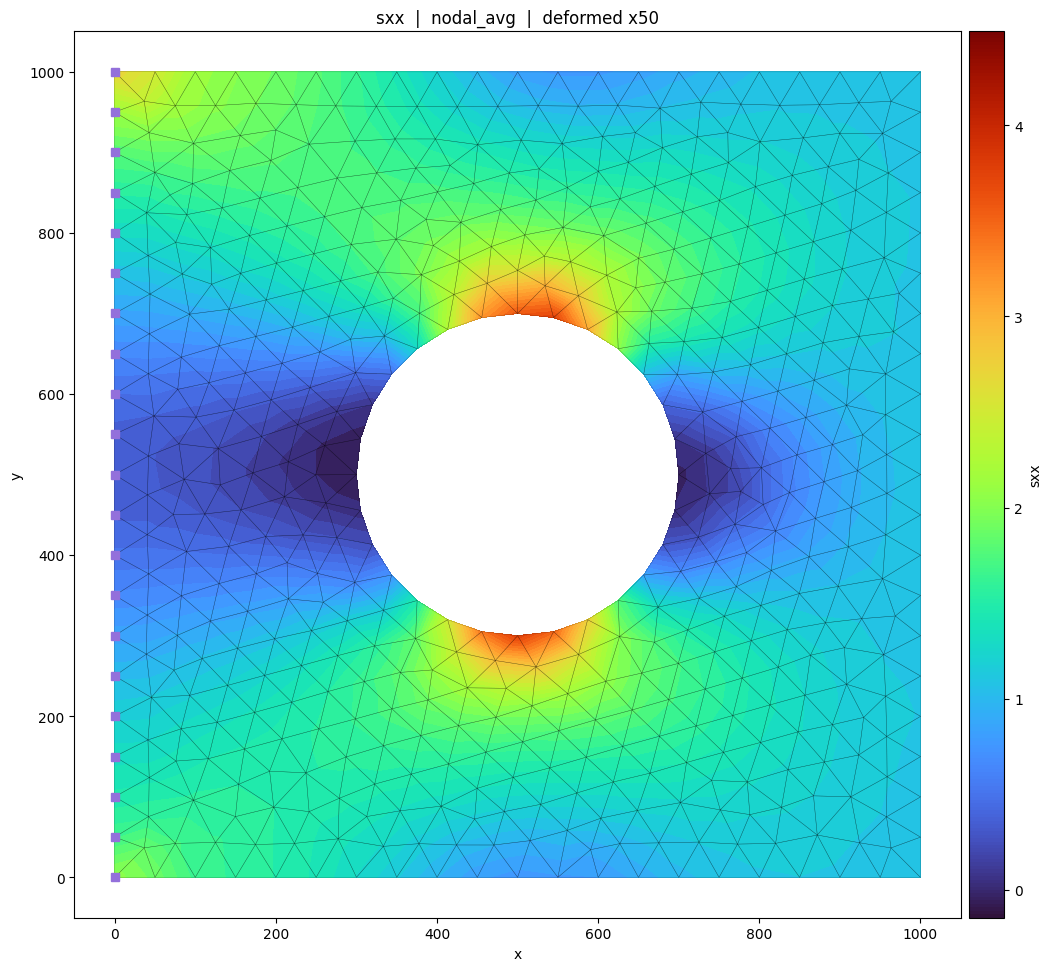

In [21]:
# Mesh
plot_mesh(
    nodes               = node_map.values(),
    elements            = elements,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Loads
plot_loads_2d(
    nodes               = node_map.values(),
    elements            = elements,
    F_load              = F_load,
    show_element_edges  = True,
    show_node_points    = True,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Deformed
plot_deformed(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    sfac                = 50,
    cmap                = 'viridis',
    limit               = None,
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Stress or Strain Field
plot_field_2d(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'sxx',       # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy','e1','e2'
    result_type         = 'nodal_avg', # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 50,
    limit               = None,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

In [22]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=2500, y=500)

Node 3 at [1000. 1000.]:  ux=+0.005986  uy=-0.001510
Node 37 at [1000.  500.]:  ux=+0.008664  uy=-0.001398


In [23]:
def get_element(elements, u, tag=None, x=None, y=None):
    """
    Returns an element by tag or by closest centroid position and prints its results.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        elem = next((e for e in elements if e.element_tag == tag), None)
        if elem is None:
            print(f"Element tag={tag} not found.")
            return None
    else:
        best_elem = None
        best_dist = np.inf
        for e in elements:
            centroid = np.mean([n.coordinates for n in e.nodes], axis=0)
            dist     = np.linalg.norm(centroid - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_elem = e
        elem = best_elem

    results  = elem.get_results(u)
    centroid = np.mean([n.coordinates for n in elem.nodes], axis=0)
    stress  = results['stress'].flatten()
    strain  = results['strain'].flatten()

    print(f"Element {elem.element_tag} at centroid {centroid}:")
    print(f"  stress : sxx={stress[0]:+.4f}  syy={stress[1]:+.4f}  sxy={stress[2]:+.4f}")
    print(f"  strain : exx={strain[0]:+.6f}  eyy={strain[1]:+.6f}  exy={strain[2]:+.6f}")

    return elem

# # By tag
# elem = get_element(elements, u, tag=10)

# By position
elem = get_element(elements, u, x=2500, y=0)

Element 798 at centroid [987.799153  28.867513]:
  stress : sxx=+1.1032  syy=-0.0022  sxy=-0.0023
  strain : exx=+0.000005  eyy=-0.000002  exy=-0.000000


## Opensees

In [29]:
# import openseespy.opensees as ops
import opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder','-ndm',2,'-ndf',2)

In [30]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y)

In [31]:
# Boundary conditions
constrained_nodes = set()

for phys_id, condition in restrain_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    for conn in mesh.elements[phys_id]['connectivity']:
        for tag in conn:
            if tag not in constrained_nodes:
                constrained_nodes.add(tag)
                ops.fix(tag, *[1 if r == 'r' else 0 for r in condition])

In [32]:
# Material
solidMaterialTag = 1

ops.nDMaterial('ElasticIsotropic', solidMaterialTag,
               Steel.E,
               Steel.nu,
               Steel.rho)

In [33]:
# Elements
for phys_id, section in section_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    group = mesh.elements[phys_id]
    for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
        ops.element('tri31', elem_tag, *conn, section.thickness, 'PlaneStress', solidMaterialTag)

Tri31 - Written by Roozbeh G. Mikola and N.Sitar, UC Berkeley


<Axes: >

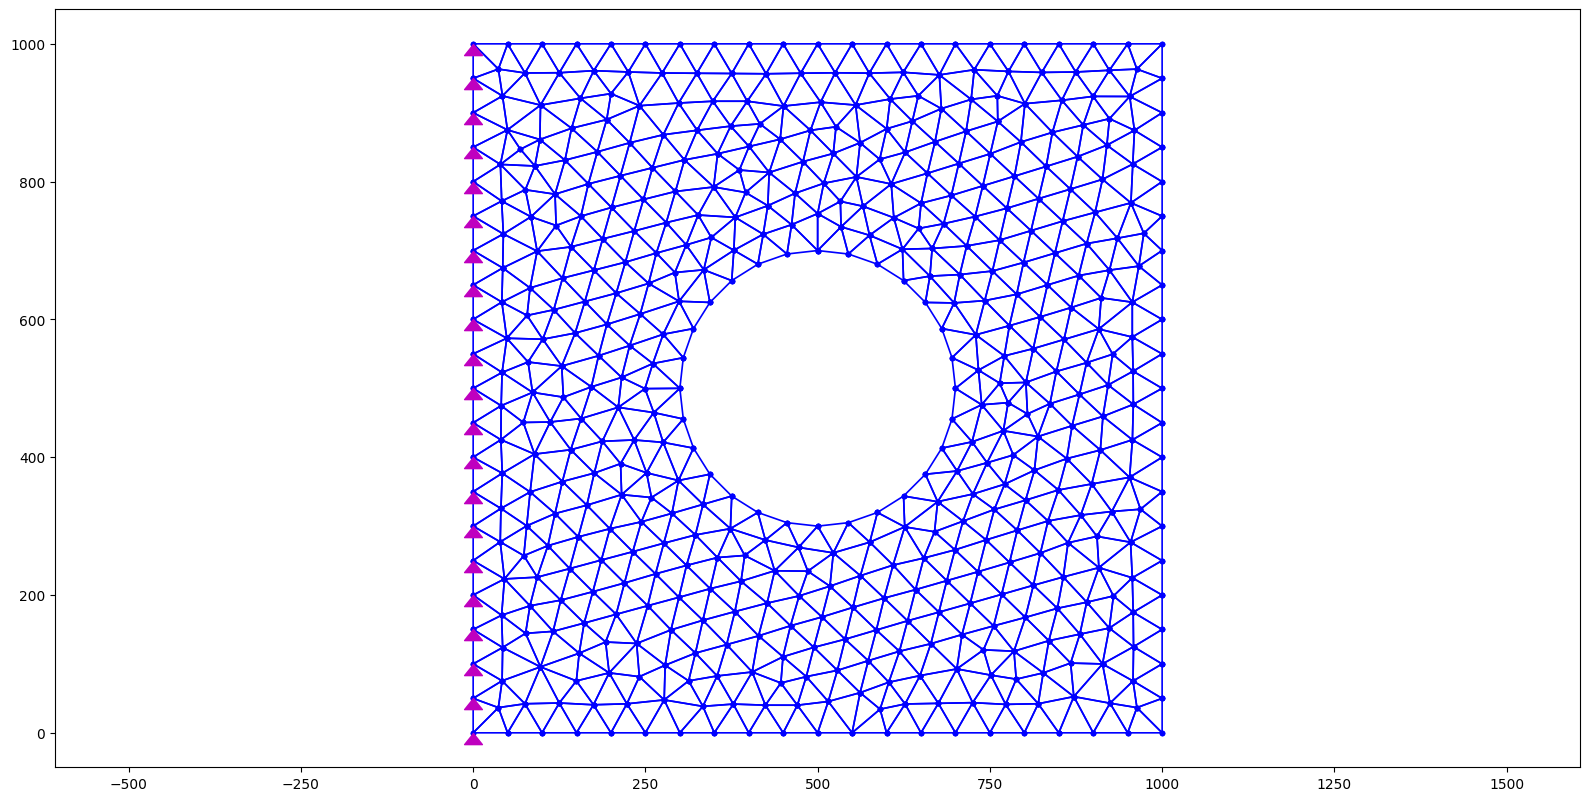

In [34]:
opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [35]:
# Loads
ts_tag      = 2
pattern_tag = 2
ops.timeSeries('Linear', ts_tag)
ops.pattern('Plain', pattern_tag, ts_tag)

for node in node_map.values():
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        ops.load(int(node.name), float(fx), float(fy))

In [36]:
NstepGravity=10
DGravity=1/NstepGravity

ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity )
ops.test("NormUnbalance", 1.0e-6, 100 , 0)
ops.algorithm("Newton")
ops.analysis("Static")

ops.analyze(NstepGravity)

0

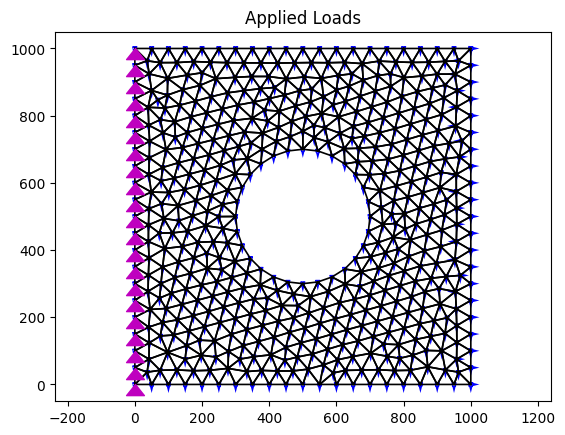

In [37]:
opsv.plot_loads_2d(sfac=0.1)
for txt in plt.gca().texts:
    txt.set_visible(False)
plt.title('Applied Loads')
plt.show()

10

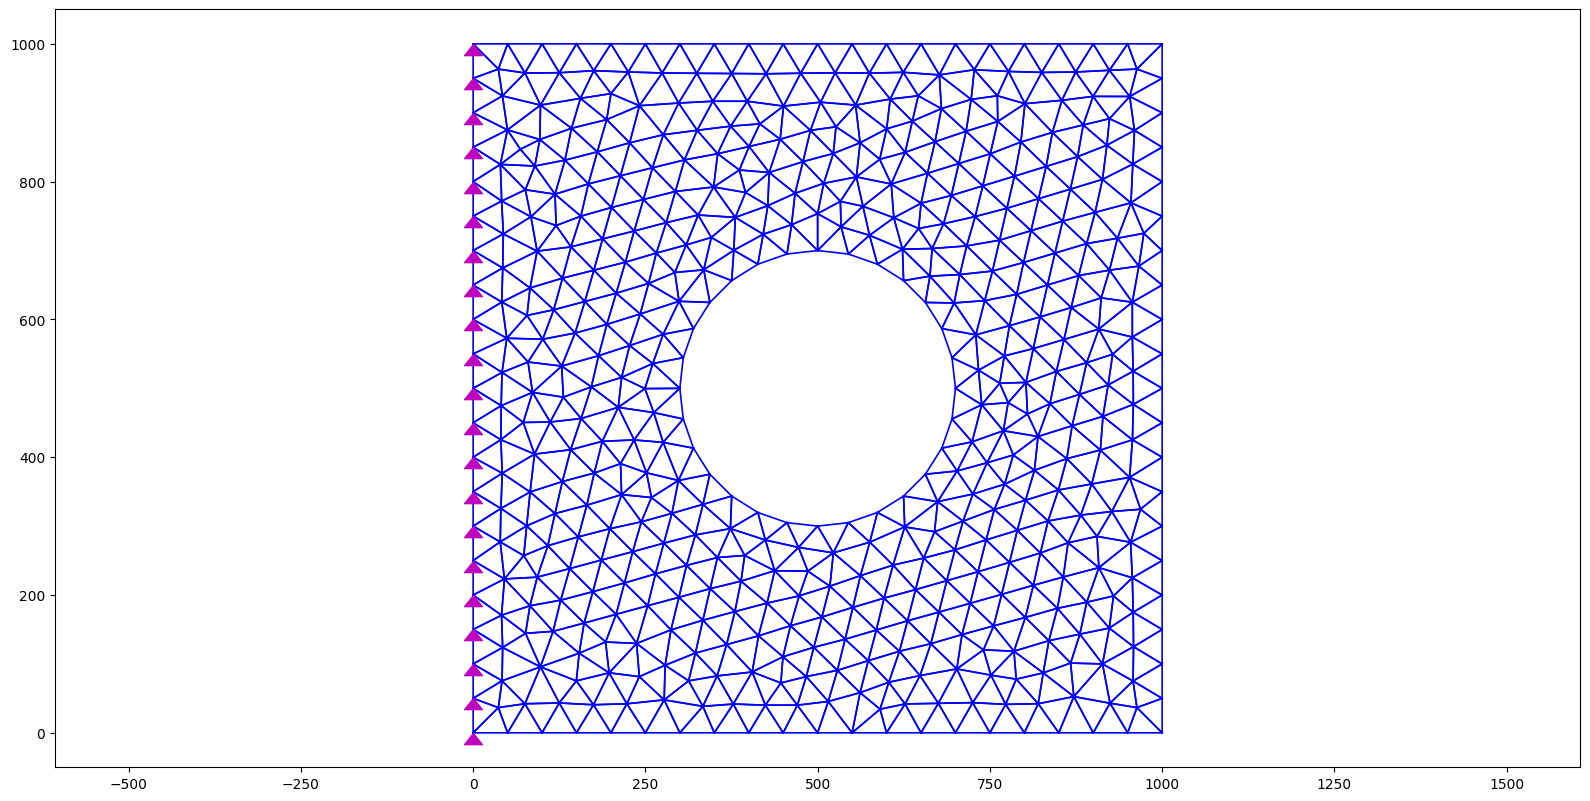

In [38]:
opsv.plot_defo(
    sfac=10,
    fig_wi_he=(50, 25),
    endDispFlag=True,
    unDefoFlag=0
)

Text(0.5, 1.0, 'sxx')

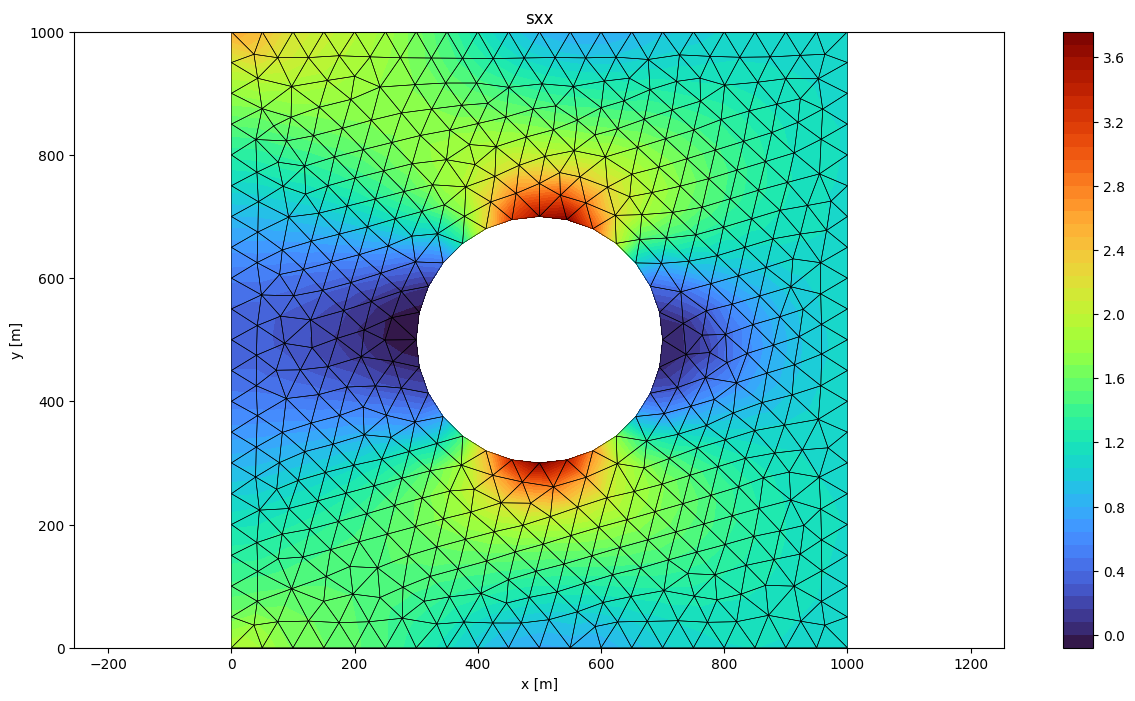

In [39]:
jstr = 'sxx'
# jstr = 'syy'
# jstr = 'sxy'
# jstr = 'vmis'
# jstr = 's1'
# jstr = 's2'
# jstr = 'angle'

plt.figure(figsize=(15, 8))
opsv.plot_stress(jstr)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title(f'{jstr}')